## Interactive Time Series Analysis Tool ##

### Motivation

This toolkit enables interactive comparison of time series forecasting methods, with options to forecast future values or evaluate model performance on historical data.

In practice, forecasting models often appear accurate in-sample but fail in real-world conditions. This tool highlights that gap through built-in backtesting and error analysis.

This follows the steps:

   - Selection of data
    
   - Initial inspection and pre-processing of the data, specifically the option to filter (e.g. selecting a specific company from *all_stocks_5yr.csv*)
    
   - Optional resampling the data (e.g. from days to business days) 
   
   - Method selection
   
   - Forecast length
   
   - Choice of whether to forecast into the future or backtest to gauge how the forecat compares with historical real world data
   
These steps can be adjusted interactively without needing to rerun the entire pipeline.

### Supported Methods

- Exponential Smoothing

- Holt-Winters (Triple Exponential)

- ARIMA / Auto-ARIMA

- Prophet (with holiday effects)

Additional methods can be incorporated as needed.

### Quick Start

Run the notebook using the default dataset (AirPassengers) to see a full workflow without interaction.

        USE_DEFAULTS = False


In [227]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline
import matplotlib
import matplotlib.ticker as ticker
from statsmodels.tsa.api import SimpleExpSmoothing
import os,sys, glob
from IPython.display import HTML, display, clear_output
import ipywidgets as widgets
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Example default values for non-interactive use
USE_DEFAULTS = True

### Data Selection

Select a dataset either from a local CSV file or via an external API.

In [228]:
csv_files = glob.glob('*.csv')
majors = ['USD', 'EUR', 'GBP', 'NZD', 'AUD', 'JPY', 'CAD', 'CHF']

dd_choice = widgets.Dropdown(options=['Local CSV', 'Currency Rates'], 
                             description='Source:', layout={'width': '30%'})
dd_file = widgets.Dropdown(options=csv_files, description='File:', value = 'AirPassengers.csv',
                           layout={'width': '40%'})
dd_cur1 = widgets.Dropdown(options=majors, value='GBP', description='From:', 
                           layout={'width': '55%'})
dd_cur2 = widgets.Dropdown(options=majors, value='NZD', description='To:', 
                           layout={'width': '55%'})


sl_days = widgets.IntSlider(value=30, min=1, max=1000, step=1, description='Days back:', 
        layout={'width': '90%'},style={'description_width': 'initial'})

# Hide currency selectors by default
cur_row = widgets.HBox([dd_cur1, dd_cur2])
slider_box = widgets.VBox([sl_days])

cur_row.layout.display = 'none'
slider_box.layout.display = 'none'

def toggle_ui(change):
    if change['new'] == 'Currency Rates':
        dd_file.layout.display = 'none'
        cur_row.layout.display = 'flex'
        slider_box.layout.display = 'flex'
    else:
        dd_file.layout.display = 'flex'
        cur_row.layout.display = 'none'
        slider_box.layout.display = 'none'

dd_choice.observe(toggle_ui, names='value')

def process_selection(mode, file, c1, c2, days):
    clear_output(wait=True)
    if mode == 'Local CSV':
        print(f"Mode: Local CSV | File: {file}")
    else:
        print(f"Mode: Currency Rates | {c1} to {c2} | Period: Last {days} days")

menu_row = widgets.HBox([dd_choice, dd_file, cur_row])

ui = widgets.VBox([menu_row, slider_box])

out = widgets.interactive_output(process_selection, {
    'mode': dd_choice, 'file': dd_file, 
    'c1': dd_cur1, 'c2': dd_cur2, 'days': sl_days
})

display(ui, out)

if USE_DEFAULTS:
    process_selection(dd_choice.value, dd_file.value, dd_cur1.value, dd_cur2.value, sl_days.value)

Mode: Local CSV | File: AirPassengers.csv


### Pre-processing

Viewing and selecting data

In [229]:
if dd_choice.value == 'Local CSV':
    df = pd.read_csv(dd_file.value)
    
else:
    #!pip install --upgrade yfinance
    import yfinance as yf
    symbol = f"{dd_cur1.value}{dd_cur2.value}=X" 
    end_date = pd.Timestamp.now()
    start_date = end_date - pd.Timedelta(days=sl_days.value)
    data = yf.download(symbol, start=start_date, end=end_date)
    df = data[['Close']]
    df.columns = df.columns.droplevel(1)
    df = df.reset_index()
    df.columns = ['Date', dd_para.value] 
 
df = df.ffill(); #print(df)

cols = df.columns

# NICE PLOT SET-UP --------------
font = 12
def spines(width,height,setup):
    if setup == 'y':
        plt.rcParams.update({'font.size': font})
        plt.figure(figsize = (width,height))
        ax = plt.gca();
    plt.setp(ax.spines.values(), linewidth=2)
    ax.tick_params(direction='in', pad = 7,length=6, width=1.5, which='major',right=True,top=True)
    ax.tick_params(direction='in', pad = 7,length=3, width=1.5, which='minor',right=True,top=True)
    return ax
#------------------------------
def plot_func(data,date,para,label):
    x = data[date]; y = data[para]
    ax = spines(10,4,'y')
    plt.xlabel('Date'); 
    if dd_choice.value == 'Local CSV':
        plt.ylabel('%s' %(para))
    else:
        plt.ylabel('%s to %s conversion' %(dd_cur1.value,dd_cur2.value))
    plt.plot(x,y, c = 'b',ls = '-',lw=1,zorder =2, label = label)
    ax.legend(fontsize = 0.8*font, loc = 'best')
        
    plt.show()
##########################
data = df
def sel(date,para):
    global data
    data[date] = pd.to_datetime(data[date]) 
    data = data.sort_values(date)
    current_label = f"{dd_cur1.value}/{dd_cur2.value} Exchange Rate" if dd_choice.value == 'Currency Rates' else "CSV Data"
    plot_func(data,date,para,label)   

In [230]:
dd_date = widgets.Dropdown(options= cols ,value=cols[0],
                            description='Select date column:',
                            style={'description_width': 'initial'},
                            layout={'width': '25%'},  disabled=False)

dd_para = widgets.Dropdown(options= cols ,value=cols[1],
                            description='y-axis:',
                            style={'description_width': 'initial'},
                            layout={'width': '25%'},  disabled=False)

ui_columns = widgets.HBox([dd_date, dd_para])

def toggle_column_selectors(change):
    # Determine the mode from the dropdown change or the direct widget value
    val = change['new'] if isinstance(change, dict) else dd_choice.value
    if val == 'Currency Rates':
        ui_columns.layout.display = 'none' 
    else:
        ui_columns.layout.display = 'flex'
dd_choice.observe(toggle_column_selectors, names='value')
toggle_column_selectors(dd_choice.value)


if dd_choice.value == 'Local CSV':
    label = "All data"
else:
    label = '%d day history' %(sl_days.value)
out = widgets.interactive_output(sel, {'date': dd_date, 'para': dd_para})
display(ui_columns, out)

Output()

If plot is too busy may have to filter the data

In [231]:
def filter_data(fil,by,match):
    if (fil == 'y') | (fil == 'Y'):
        choices = df[by].unique()
        choices.sort()
        tmp = df[df[by] == match] 
        tmp = tmp[[dd_date.value,dd_para.value]]
    else:
        tmp = df[[dd_date.value,dd_para.value]]
    return tmp

In [232]:
dd_fil = widgets.Dropdown(options= ['y','n'] ,value='n',
                            description='Filter data:',
                            layout={'width': '15%'},  disabled=False)

dd_by = widgets.Dropdown(options= cols ,value=cols[1],
                            description='Filter field:',
                            layout={'width': '25%'},  disabled=False)


initial_opts = sorted(df[dd_by.value].unique())
dd_m = widgets.Dropdown(options=initial_opts, value=initial_opts[0], description='Match by:', layout={'width': '25%'})

def update_dd_m(change):
    new_options = sorted(df[change['new']].unique())
    dd_m.options = new_options
    dd_m.value = new_options[0]

dd_by.observe(update_dd_m, names='value')

def process_and_plot(fil, by, match):
    if dd_fil.value == 'y':
        print(f"Filtering by {by}: {match}")
        data = filter_data(fil,by,match)
        label = "%s" %(dd_m.value)
        plot_func(data,dd_date.value,dd_para.value,match) 
        
    else:
        print('No filtering to apply')
        
out = widgets.interactive_output(process_and_plot, {'fil': dd_fil, 'by': dd_by, 'match': dd_m})

ui = widgets.HBox([dd_fil, dd_by, dd_m])
display(ui, out)

if USE_DEFAULTS:
    process_and_plot(dd_fil.value, dd_by.value, dd_m.value)

Output()

No filtering to apply


### Define Time Series Methods

Can choose from:

 - *Simple Exponential Smoothing*: For data with no clear trend or seasonal pattern. Best for quiet data; forecasts a flat line.
 
 - *Double Exponential Smoothing* (Holt’s Linear Trend): For a trend in the data, but no seasonality. Captures trend; forecasts a sloped line.

 - *Triple Exponential Smoothing* (Holt-Winters): Where there is both trend and seasonality, ideal for rhythmic business data
 
 - *ARIMA*:  (AutoRegressive Integrated Moving Average): Combines autoregression (AR - *p*), diﬀerencing (I - *d*) and moving averages (MA - *q*) of forecast errors to analyze trends and patterns. Utilized via auto ARIMA, which automates the *p,d,q* hyperparameters. High statistical rigor; handles complex trends through autoregression but can be slow to auto-tune
 
 - *Prophet*: Developed by Meta, this is designed to be robust to missing data, outliers, and dramatic shifts in trend. Handles missing data well and is uniquely capable of modelling holiday effects and multiple seasonal patterns.
 
Machine and deep learning (e.g. *Long Short-Term Memory*) methods not included as require very specific processing and can suffer from compatiability issues (e.g. with the Apple M1 chip). The above methods are compared with these for some specific cases, [below](#ML).

In [233]:
def exp_smoothing(data,L,alg): 
    if alg == 'Simple exponential':
        model = SimpleExpSmoothing(data)
        model_name = 'Simple'
    elif alg == 'Double exponential':
        from statsmodels.tsa.api import Holt
        model = Holt(data)
        model_name = 'Double'
    else:
        from statsmodels.tsa.api import ExponentialSmoothing
        model = ExponentialSmoothing(data,trend='add',seasonal='add')
        model_name = 'Triple'   
    fit = model.fit() 
    label = r'%s exponential: $\alpha$ = %1.4f' %(model_name, fit.model.params['smoothing_level'])
    fcast = fit.forecast(L)
    return fit,fcast,label,model_name

def arima(data,L,m):
    #!pip install --upgrade pmdarima
    #Libraries like pmdarima (used for auto ARIMA) are compiled against specific internal structures of NumPy.
    print('************************************************')
    print('Running auto ARIMA, please wait can take a while')
    print('************************************************')
    m_mapping = {'days': 7, 'business days' :7,'weeks': 52, 'months (end)': 12, 'months (start)': 12}
    m_value = m_mapping.get(dd_freq.value, 1)

    from pmdarima import auto_arima
    model = auto_arima(data, seasonal=True, m = m_value) 
    print(model.summary())
    fit = model.predict_in_sample()
    model_name = 'ARIMA'
    fcast = model.predict(n_periods=L)
    p, d, q = model.order
    P, D, Q, s = model.seasonal_order 
    if s > 0:
        label = r'ARIMA (%d,%d,%d)(%d,%d,%d)[%d]' %(p,d,q,P,D,Q,s)
    else:
        label = r'ARIMA (%d,%d,%d)' %(p,d,q)
    return fit,fcast,label,model_name

def prophet(data,L,hol_name):
    #%pip install Prophet  
    from prophet import Prophet
    model_name = 'Prophet'
    label = 'Prophet'
    
    df_p = pd.DataFrame()
    df_p['ds'] = pd.to_datetime(data.index).tz_localize(None)
    df_p['y'] = data[dd_para.value].values.flatten()
    
    m = Prophet()
    if hol_name != "None":
        country_code = dfc[dfc['Country '] == hol_name]['Code'].values[0]
        m.add_country_holidays(country_name=country_code)
    m.fit(df_p)
    
    #print(dd_freq.value)
    future = m.make_future_dataframe(periods=int(L), freq=cfreq)
    forecast = m.predict(future)
    forecast.index = pd.to_datetime(forecast['ds'])
    fitted_values = pd.Series(forecast['yhat'].iloc[:-int(L)].values, index=data.index)
    fcast= forecast['yhat'].iloc[-int(L):]
    return m, fcast, label, model_name, fitted_values

def plot_func2(model_name,fitted_data,fcast_data,rem_data,label_in,length,freq_name,df_to_plot,zoom_start):
    #ax = spines(10,4,'y') # CLASHES WITH THE ZOOM OPTION
    plt.rcParams.update({'font.size': font})
    plt.rcParams['legend.handlelength'] = 1.5
    
    plt.figure(figsize = (10,4))
    ax = plt.gca();
    plt.setp(ax.spines.values(), linewidth=2)
    ax.tick_params(direction='in', pad = 7,length=6, width=1.5, which='major',right=True,top=True)
    ax.tick_params(direction='in', pad = 7,length=3, width=1.5, which='minor',right=True,top=True)
    
    zoom_start = pd.to_datetime(zoom_start).tz_localize(None)
   
    if model_name == 'ARIMA':
        fitted_vals = fitted_data
    else:
        fitted_vals = fitted_data.values 
    fit_plot = fitted_data.index
    
    fp = '%d %s forecast period' %(length, freq_name)

    if dd_ft.value == 'Test':
        actuals = rem_data[dd_para.value].astype(float).values
        forecasts = fcast_data.astype(float).values
        errors = forecasts - actuals
        mse = np.mean(errors**2)
        rmse = np.sqrt(mse)
        mean_actual = np.mean(actuals)
        npd = 100 * rmse / mean_actual
    
        print('Over %d %s between the forecast and the data the normalised difference is NPD = %1.2f%% (RMSE = %1.2f)'
              % (length, freq_name,npd,rmse))
        label = fp + r'$\Rightarrow$ RMSE = %1.2f, NPD = %1.2f%%' %(rmse,npd)
        
    else:
        label = fp 
            
    ax.plot(df_to_plot.index, df_to_plot[dd_para.value], label='Actual data', color='k', zorder=1)
    ax.plot(fitted_data.index, fitted_data.values, ls='--', c='b', lw=1.5, label=label_in,zorder=2)
    ax.plot(fcast_data.index, fcast_data.values, c='r', ls='dotted', lw=2, label=label, zorder=3)
    if not rem_data.empty:
        ax.plot(rem_data.index, rem_data[dd_para.value], color='k', ls='',zorder=1)
    ax.axvspan(fcast_data.index[0],fcast_data.index[-1], color='silver', alpha=0.3, zorder=1)   
    
    padding_map = {'days': 2, 'weeks': 2, 'months (start)': 2, 'months (end)': 2}
    days_to_add = padding_map.get(freq_name, 7)
    ax.set_xlim(left=zoom_start, right=fcast_data.index[-1]+ pd.Timedelta(days=days_to_add))
    
    plt.xlabel('Date'); 
    if dd_choice.value == 'Local CSV':
        plt.ylabel('%s' %(dd_para.value))
    else:
        plt.ylabel('%s to %s conversion' %(dd_cur1.value,dd_cur2.value))
    
    visible_data = df_to_plot[df_to_plot.index >= zoom_start][dd_para.value]
    #ignores every row before zoom start and selects column of interest
    
    if not visible_data.empty:
        ymin = visible_data.min()
        ymax = max(visible_data.max(), fcast_data.max()) # Include forecast height
        padding = (ymax - ymin) * 0.1
        ax.set_ylim(ymin - padding, ymax + padding)
    
    ax.legend(fontsize = 0.8*font, loc = 'upper left')
    #plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

 ### Forecast
 
 Here we can:
 
 - Resample the data, specifically if *days* should be *business days* (Monday - Friday). Resampling to the native time interval may also remove the "no frequency information" warning
 
 - Choose forecast algorithm
 
 - Select length of forecast
 
 - Have the option to test the forecast. This reserves the most recent  data, according to the forecast length, to  be compared directly with the predicted values. That is, how well the model performs on unseen data. 

	- The result is quantified via the *root mean square error*, 
    
      RMSE = $\sqrt{\frac{1}{n}\sum_{i=1}^n(\hat{y} - y_i)^2}$. 

    - The *normalised percentage difference*, which scales the RMSE over the mean value of the observed data over the forecast period, 
    
      NPD $\equiv 100\times{\rm RMSE}/\mu_{\rm actual}$.
      
 
 - Zoom in on the forecast range for a closer inspection
 

In [234]:
# To ensure zooming doesn't rerun the entire function
last_results = {'params': None, 'fit': None, 'fcast': None, 'rem': None, 'label': None, 'model': None}

No resampling from months (start) (MS)
Zooming... (Displaying cached model results)


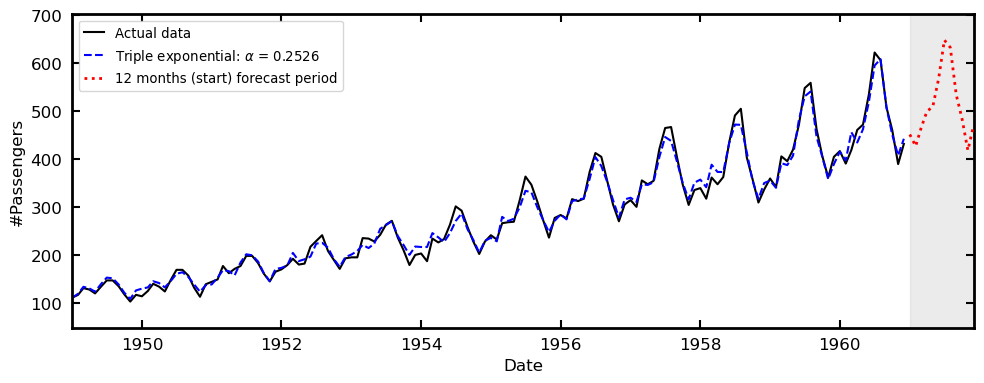


### Summary
- **Model used:** Triple exponential
- **Forecast horizon:** 12 months (start)
- **RMSE:** nan
- **Normalised Percentage Difference:** nan%


In [236]:
from IPython.display import Markdown, display

data = filter(dd_fil.value,dd_by.value,dd_m.value)
date = data.columns[0]
data.sort_values(date, inplace = True)
data.set_index(date, inplace=True)

conv = {'days':'D','business days':'B','weeks':'W','months (start)':'MS', 'months (end)':'M'}
swapped_conv = {value: key for key, value in conv.items()}
cfreq = pd.infer_freq(data.index)
cfreq_text = swapped_conv.get(cfreq)

print('Current frequency is %s (%s)' %(cfreq_text,cfreq))

def display_summary(alg, length, freq, rmse, nprd):
    summary_text = f"""
### Summary
- **Model used:** {alg}
- **Forecast horizon:** {length} {freq}
- **RMSE:** {rmse:.4f}
- **Normalised Percentage Difference:** {nprd:.4f}%
"""
    display(Markdown(summary_text))

def resample(sample,freq,fot,length,alg,zoom_start,hol):
    global last_results
    clear_output(wait=True) 
    
    if sample == 'y':
        per = conv.get(freq)
        print(per)
        data2 = data.asfreq(per)
        data2[dd_para.value] = data2[dd_para.value].interpolate()
        data2.index.freq = per 
        print('Resampled to %s (%s)' % (per, freq))    
    else:
        print('No resampling from %s (%s)' % (cfreq_text, cfreq))
        data2 = data.copy()
     
    if fot == "Test":
        test_data = data2[:-length] 
        rem_data = data2[-length:]
    else:
        test_data = data2.copy()
        rem_data = pd.DataFrame()
        
    ### CACHE CHECK: If everything but the zoom is the same, just plot!
    current_params = (sample, freq, fot, length, alg,hol)
    # Use .get() and check if last_results is a valid dictionary
    if isinstance(last_results, dict) and last_results.get('params') == current_params:
        if 'fcast' in last_results: # Ensure the model actually succeeded before
            print("Zooming... (Displaying cached model results)")
            plot_func2(last_results['model'], last_results['fit'], 
                       last_results['fcast'], rem_data, 
                       last_results['label'], length, freq, data2, zoom_start)
            display_summary(alg, length, freq, last_results.get('rmse', np.nan), last_results.get('nprd', np.nan))
            return data2
     ####################################################################   
    try:
        fcast = None 
        target_series = test_data[dd_para.value].squeeze()
         
        if dd_alg.value == 'ARIMA':
            fit_array, fcast, label_in, model_name = arima(target_series, length, m=1)
            fitted_to_plot = pd.Series(fit_array, index=target_series.index)
        
        elif dd_alg.value == 'Prophet':  
            fit_obj, fcast, label_in, model_name, fitted_to_plot = prophet(test_data, length,hol)
            
        else:
            fit_obj, fcast, label_in, model_name = exp_smoothing(target_series, length, dd_alg.value)
            fitted_to_plot = fit_obj.fittedvalues
            
        # --- CALCULATE METRICS HERE ---
        if fot == "Test" and not rem_data.empty:
            actuals = rem_data[dd_para.value].values
            predictions = fcast.values[:len(actuals)]
            current_rmse = np.sqrt(np.mean((actuals - predictions)**2))
            current_nprd = (current_rmse / np.mean(actuals)) * 100
        else:
            current_rmse = np.nan
            current_nprd = np.nan
        # ------------------------------
            
        full_index = data2.index.append(fcast.index)
        sl_zoom.options = [(d.strftime('%Y-%m-%d'), d) for d in full_index]
        
        last_results = {'fcast': fcast, 'fit': fitted_to_plot, 'label': label_in, 'model': model_name, 
                'params': current_params} #SAVE TO CACHE FOR NEXT TIME
        
        plot_func2(model_name,fitted_to_plot,fcast,rem_data, label_in, length, freq, data2, zoom_start)
        display_summary(alg, length, freq, current_rmse, current_nprd)
        
        
    except Exception as e:
        print(f"Model error: {e}") 

    return data2

dd_samp = widgets.Dropdown(options= ['n','y'] ,value='n',
                            description='Resample dates:',
                            style={'description_width': 'initial'},
                            layout={'width': '25%'},  disabled=False)

dd_freq = widgets.Dropdown(options= ['days','business days','weeks', 'months (start)', 'months (end)'],
                           value = cfreq_text,
                            description='Required time intervals:',
                            style={'description_width': 'initial'},
                            layout={'width': '30%'},  disabled=False)

dd_alg = widgets.Dropdown(options= ['Simple exponential','Double exponential','Triple exponential','ARIMA','Prophet'],
                           value = 'Triple exponential',
                            description='Forecast algorithm:',
                            style={'description_width': 'initial'},
                            layout={'width': '30%'},  disabled=False)

dd_fl = widgets.IntSlider(value=12,min=1,max=31, step=1,
                            description='Length of forecast in %s:' %(dd_freq.value),
                              style={'description_width': 'initial'},
                             layout={'width': '60%'}, disabled=False)

dd_ft = widgets.Dropdown(options= ['Forecast','Test'] ,value='Forecast',
                            description='Forecast or test:',
                            style={'description_width': 'initial'},
                            layout={'width': '30%'},  disabled=False)

import io
#-------- HOLIDAYS FOR PROPHET
raw = """Country 	Code	2025 GDP (Trillion USD)
United States	US	$30.62
China	CN	$19.40
Germany	DE	$5.01
Japan	JP	$4.28
India	IN	$4.13
United Kingdom	UK	$3.96
France	FR	$3.36
Italy	IT	$2.54
Russia	RU	$2.54
Canada	CA	$2.28
Brazil	BR	$2.26
Spain	ES	$1.89
Mexico	MX	$1.86
South Korea	KR	$1.86
Australia	AU	$1.83"""  
#----------------------------------

dfc = pd.read_csv(io.StringIO(raw), sep='\t')
#print(dfc.columns)
couns = list(dfc['Country '])
couns.insert(0, "None")

dd_hol = widgets.Dropdown(options= couns,value='None',
                            description='Prophet is selected - include holidays for:',
                            style={'description_width': 'initial'},
                            layout={'width': '40%'},  disabled=False)

def update_slider_range(change):
    new_freq = change['new']

    if new_freq in ['days', 'business days']:
        new_max = 31
    elif new_freq == 'weeks':
        new_max = 12
    else: # months
        new_max = 12
        
    dd_fl.max = new_max
    dd_fl.description = f'Length of required forecast in {new_freq}:'

    if dd_fl.value > new_max:
        dd_fl.value = new_max

dd_freq.observe(update_slider_range, names='value')
    
# ZOOM IN SLIDER OPTION
date_options = [(d.strftime('%Y-%m-%d'), d) for d in data.index]
sl_zoom = widgets.SelectionSlider(options=date_options,value=date_options[0][1],
    description='Plot start date:',layout={'width': '90%'},
                style={'description_width': 'initial'},continuous_update=False)

def show_forecast_info(freq, length):
    print(f"\nIn the last dropdown you can choose to do a {length} {freq} forecast")
    print("or reserve this time period against which to test the model")  
    
ui = widgets.HBox([dd_samp,dd_freq, dd_alg])
ui2 = widgets.HBox([dd_fl, dd_ft])
hol_box = widgets.HBox([dd_hol])
hol_box.layout.display = 'none' if dd_alg.value != 'Prophet' else 'flex'
def toggle_holidays(change):
    if change['new'] == 'Prophet':
        hol_box.layout.display = 'flex'
    else:
        hol_box.layout.display = 'none'

dd_alg.observe(toggle_holidays, names='value')
resamp_dict = {'sample': dd_samp, 'freq': dd_freq, 'fot': dd_ft, 'length': dd_fl, 
               'alg': dd_alg, 'zoom_start': sl_zoom, 'hol': dd_hol}
out = widgets.interactive_output(resample, resamp_dict)
display(ui, ui2, hol_box, sl_zoom, out)

if USE_DEFAULTS:
    resample(sample=dd_samp.value,freq=dd_freq.value,fot=dd_ft.value,
             length=dd_fl.value,alg=dd_alg.value,zoom_start=sl_zoom.value,hol=dd_hol.value) 

### <a id='ML'>Comparison with Machine and Deep Learning Methods</a> ###

**Case 1: Random Forest**

Using the *daily-total-female-births.csv* dataset [Random Forest for Time Series Forecasting](https://machinelearningmastery.com/random-forest-for-time-series-forecasting/), gives the forecast shown in the plot below, which we see has lost the date information. Over the 12 day period between the actual and forecast data, RMSE $=7.00$ and NPD $=16.7$%
![](https://raw.githubusercontent.com/steviecurran/time-series-toolkit/refs/heads/main/births.png).   

Appling the *Triple Exponential* and the *auto ARIMA*, SARIMAX(1, 1, 1) x (2, 0, [1, 2], 7), methods give similar results to the *Random Forest* forecast over the 12 day period.

![](https://raw.githubusercontent.com/steviecurran/time-series-toolkit/refs/heads/main/births_triple-exp.png)

![](https://raw.githubusercontent.com/steviecurran/time-series-toolkit/refs/heads/main/births_ARIMA.png)


**Case 2: Neural Network**

Using the *monthly_milk_production.csv* dataset from [Long short-term memory (LSTM) RNN in Tensorflow](https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-lstm-rnn-in-tensorflow/), shown below.
![](https://raw.githubusercontent.com/steviecurran/time-series-toolkit/refs/heads/main/milk_prodiction.png)

Applying the Triple Exponential gives a better forecast than the LTSME method, with the auto ARIMA, SARIMAX(3, 0, 1) x (0, 1, 1, 12) being similar in metrics over the 30 month period.

![](https://raw.githubusercontent.com/steviecurran/time-series-toolkit/refs/heads/main/milk_prodiction-triple_exp.png)

![](https://raw.githubusercontent.com/steviecurran/time-series-toolkit/refs/heads/main/milk_prodiction-ARIMA.png)
